# Import Libraries

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

In [45]:
# Load dataset
df = pd.read_csv("iran_war_gas_prices_by_state.csv")
df.head()

,state,region,gas_price_mar19_2026,gas_price_prewar_feb27,gas_price_jan08_2026,price_increase_since_war,pct_increase_since_war,price_vs_national_avg,source
0,California,West,5.53,4.52,3.88,1.01,22.3,1.65,"AAA State Gas Price Averages — March 19, 2026"
1,Washington,West,5.15,4.18,3.42,0.97,23.2,1.27,"AAA State Gas Price Averages — March 19, 2026"
2,Hawaii,West,5.07,4.02,3.78,1.05,26.1,1.19,"AAA State Gas Price Averages — March 19, 2026"
3,Oregon,West,4.70,3.82,3.22,0.88,23.0,0.82,"AAA State Gas Price Averages — March 19, 2026"
4,Nevada,West,4.66,3.72,3.18,0.94,25.3,0.78,"AAA State Gas Price Averages — March 19, 2026"


# Basic Information About Dataset

In [48]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(50, 9)
Index(['state', 'region', 'gas_price_mar19_2026', 'gas_price_prewar_feb27',
       'gas_price_jan08_2026', 'price_increase_since_war',
       'pct_increase_since_war', 'price_vs_national_avg', 'source'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   state                     50 non-null     object 
 1   region                    50 non-null     object 
 2   gas_price_mar19_2026      50 non-null     float64
 3   gas_price_prewar_feb27    50 non-null     float64
 4   gas_price_jan08_2026      50 non-null     float64
 5   price_increase_since_war  50 non-null     float64
 6   pct_increase_since_war    50 non-null     float64
 7   price_vs_national_avg     50 non-null     float64
 8   source                    50 non-null     object 
dtypes: float64(6), object(3)
memory usage: 3.6+ KB
None
  

# Check Missing Values

In [51]:
print(df.isnull().sum())

state                       0
region                      0
gas_price_mar19_2026        0
gas_price_prewar_feb27      0
gas_price_jan08_2026        0
price_increase_since_war    0
pct_increase_since_war      0
price_vs_national_avg       0
source                      0
dtype: int64


# Clean Column Names

In [54]:
df.columns = df.columns.str.strip().str.lower()
df.head()

,state,region,gas_price_mar19_2026,gas_price_prewar_feb27,gas_price_jan08_2026,price_increase_since_war,pct_increase_since_war,price_vs_national_avg,source
0,California,West,5.53,4.52,3.88,1.01,22.3,1.65,"AAA State Gas Price Averages — March 19, 2026"
1,Washington,West,5.15,4.18,3.42,0.97,23.2,1.27,"AAA State Gas Price Averages — March 19, 2026"
2,Hawaii,West,5.07,4.02,3.78,1.05,26.1,1.19,"AAA State Gas Price Averages — March 19, 2026"
3,Oregon,West,4.70,3.82,3.22,0.88,23.0,0.82,"AAA State Gas Price Averages — March 19, 2026"
4,Nevada,West,4.66,3.72,3.18,0.94,25.3,0.78,"AAA State Gas Price Averages — March 19, 2026"


# Check Duplicates

In [57]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [59]:
df = df.drop_duplicates()

# Convert Numeric Columns

In [62]:
numeric_cols = [
    'gas_price_mar19_2026',
    'gas_price_prewar_feb27',
    'gas_price_jan08_2026',
    'price_increase_since_war',
    'pct_increase_since_war',
    'price_vs_national_avg'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Descriptive Statistics

In [65]:
df[numeric_cols].describe()

,gas_price_mar19_2026,gas_price_prewar_feb27,gas_price_jan08_2026,price_increase_since_war,pct_increase_since_war,price_vs_national_avg
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,3.836200,3.030000,2.669600,0.806200,26.788000,-0.043800
std,0.483038,0.417949,0.339465,0.071796,1.678512,0.483038
min,3.240000,2.540000,2.280000,0.680000,22.300000,-0.640000
25%,3.520000,2.760000,2.460000,0.760000,25.950000,-0.360000
50%,3.720000,2.900000,2.580000,0.800000,27.350000,-0.160000
75%,3.955000,3.135000,2.755000,0.840000,27.875000,0.075000
max,5.530000,4.520000,3.880000,1.050000,31.000000,1.650000


In [67]:
print(df[numeric_cols].dtypes)

gas_price_mar19_2026        float64
gas_price_prewar_feb27      float64
gas_price_jan08_2026        float64
price_increase_since_war    float64
pct_increase_since_war      float64
price_vs_national_avg       float64
dtype: object


# Top 10 States with Highest Gas Price Increase

In [70]:
top10_increase = df.sort_values(by='price_increase_since_war', ascending=False).head(10)
print(top10_increase[['state', 'price_increase_since_war']])

           state  price_increase_since_war
2         Hawaii                      1.05
0     California                      1.01
1     Washington                      0.97
4         Nevada                      0.94
3         Oregon                      0.88
42      Kentucky                      0.88
6         Alaska                      0.86
7           Utah                      0.86
13      Illinois                      0.84
29  Pennsylvania                      0.84


# Visualization

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16512\2151247368.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_increase, x='price_increase_since_war', y='state', palette='coolwarm')


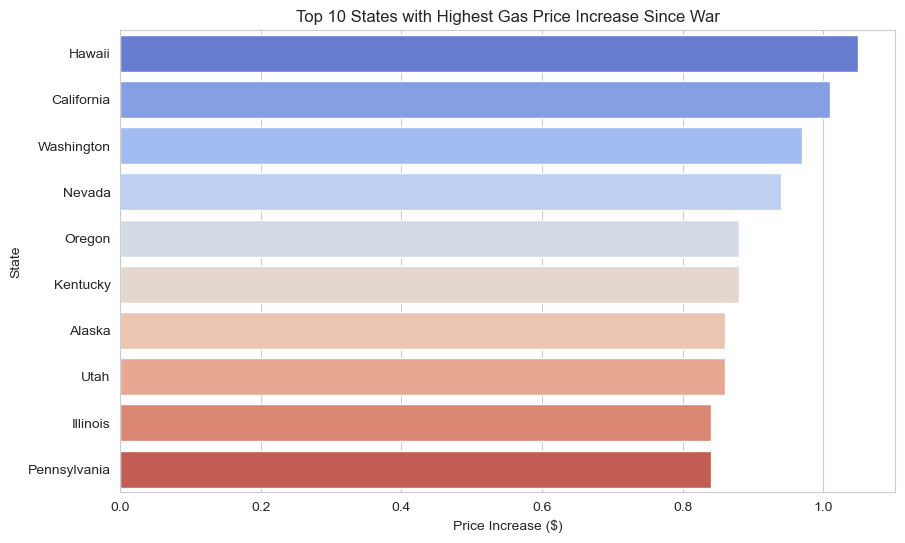

In [73]:
sns.barplot(data=top10_increase, x='price_increase_since_war', y='state', palette='coolwarm')
plt.title("Top 10 States with Highest Gas Price Increase Since War")
plt.xlabel("Price Increase ($)")
plt.ylabel("State")
plt.show()

# Top 10 States by Percentage Increase

In [76]:
top10_pct = df.sort_values(by='pct_increase_since_war', ascending=False).head(10)
print(top10_pct[['state', 'pct_increase_since_war']])

          state  pct_increase_since_war
42     Kentucky                    31.0
46     Arkansas                    28.6
7          Utah                    28.5
44      Alabama                    28.4
23     Nebraska                    28.4
16      Indiana                    28.3
11     Colorado                    28.2
39      Georgia                    28.1
47    Louisiana                    28.1
45  Mississippi                    28.0


# Visualization

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16512\1073413318.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_pct, x='pct_increase_since_war', y='state',palette='coolwarm')


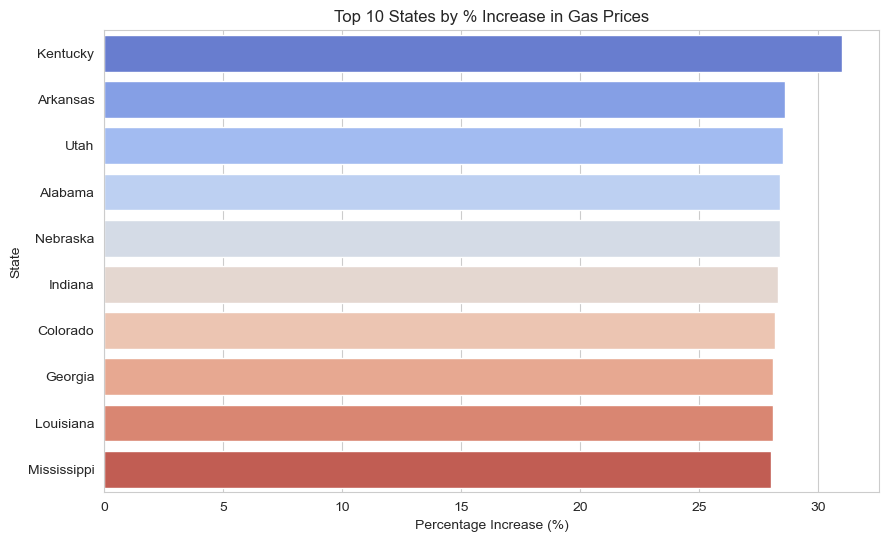

In [79]:
sns.barplot(data=top10_pct, x='pct_increase_since_war', y='state',palette='coolwarm')
plt.title("Top 10 States by % Increase in Gas Prices")
plt.xlabel("Percentage Increase (%)")
plt.ylabel("State")
plt.show()

# Average Gas Price by Region

In [81]:
region_avg = df.groupby('region')[['gas_price_mar19_2026', 'price_increase_since_war']].mean().sort_values(
    by='gas_price_mar19_2026', ascending=False
)
print(region_avg)

           gas_price_mar19_2026  price_increase_since_war
region                                                   
West                   4.322308                  0.871538
Northeast              3.963636                  0.818182
Midwest                3.551667                  0.761667
South                  3.528571                  0.774286


# Visualization

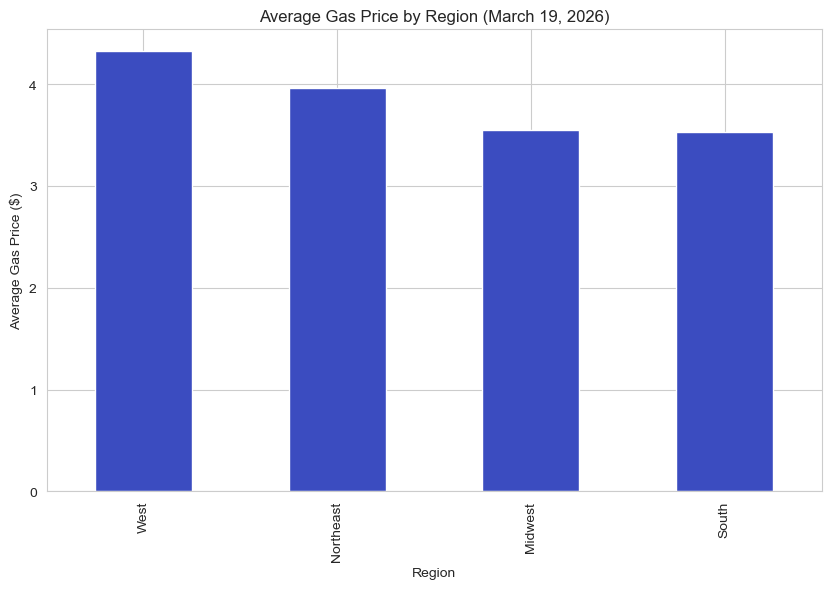

In [88]:
region_avg['gas_price_mar19_2026'].plot(kind='bar',colormap='coolwarm')
plt.title("Average Gas Price by Region (March 19, 2026)")
plt.ylabel("Average Gas Price ($)")
plt.xlabel("Region")
plt.show()

# Compare Pre-War and Post-War Average Prices

In [119]:
avg_prewar = df['gas_price_prewar_feb27'].mean()
avg_postwar = df['gas_price_mar19_2026'].mean()

print("Average pre-war gas price:", avg_prewar)
print("Average post-war gas price:", avg_postwar)
print("Average increase:", avg_postwar - avg_prewar)

Average pre-war gas price: 3.03
Average post-war gas price: 3.8361999999999994
Average increase: 0.8061999999999996


# States Above National Average

In [121]:
above_avg = df[df['price_vs_national_avg'] > 0]
print("Number of states above national average:", above_avg.shape[0])
print(above_avg[['state', 'price_vs_national_avg']].head(10))

Number of states above national average: 16
         state  price_vs_national_avg
0   California                   1.65
1   Washington                   1.27
2       Hawaii                   1.19
3       Oregon                   0.82
4       Nevada                   0.78
5      Arizona                   0.14
6       Alaska                   0.60
8        Idaho                   0.06
13    Illinois                   0.04
25    New York                   0.34


# Correlation Analysis

In [123]:
corr = df[numeric_cols].corr()
print(corr)

                          gas_price_mar19_2026  gas_price_prewar_feb27  \
gas_price_mar19_2026                  1.000000                0.997726   
gas_price_prewar_feb27                0.997726                1.000000   
gas_price_jan08_2026                  0.988782                0.984971   
price_increase_since_war              0.919821                0.891287   
pct_increase_since_war               -0.734115               -0.777132   
price_vs_national_avg                 1.000000                0.997726   

                          gas_price_jan08_2026  price_increase_since_war  \
gas_price_mar19_2026                  0.988782                  0.919821   
gas_price_prewar_feb27                0.984971                  0.891287   
gas_price_jan08_2026                  1.000000                  0.918597   
price_increase_since_war              0.918597                  1.000000   
pct_increase_since_war               -0.716412                 -0.415119   
price_vs_national_avg    

# Heatmap

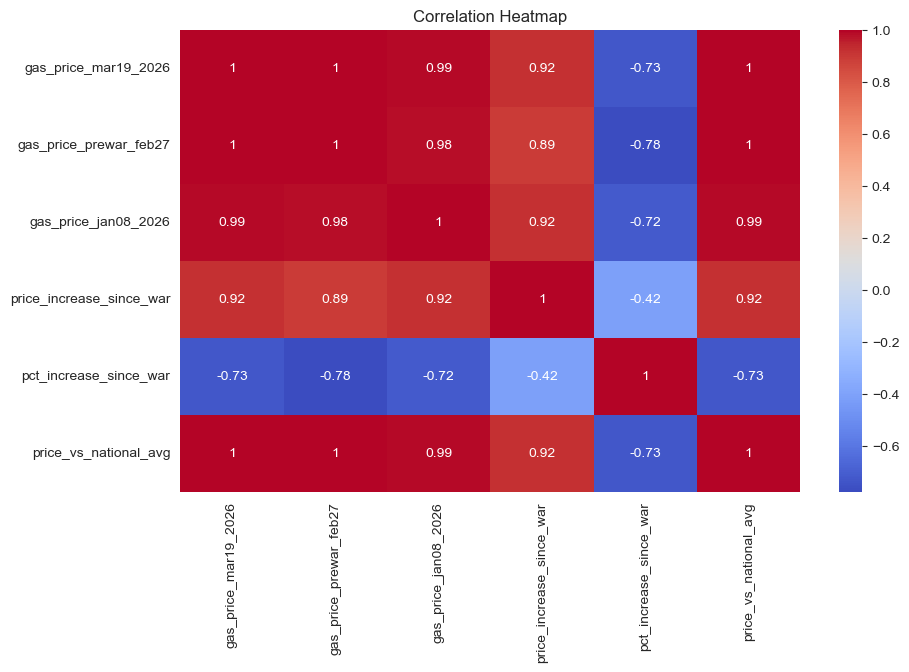

In [125]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter Plot: Current Gas Price vs Price Increase

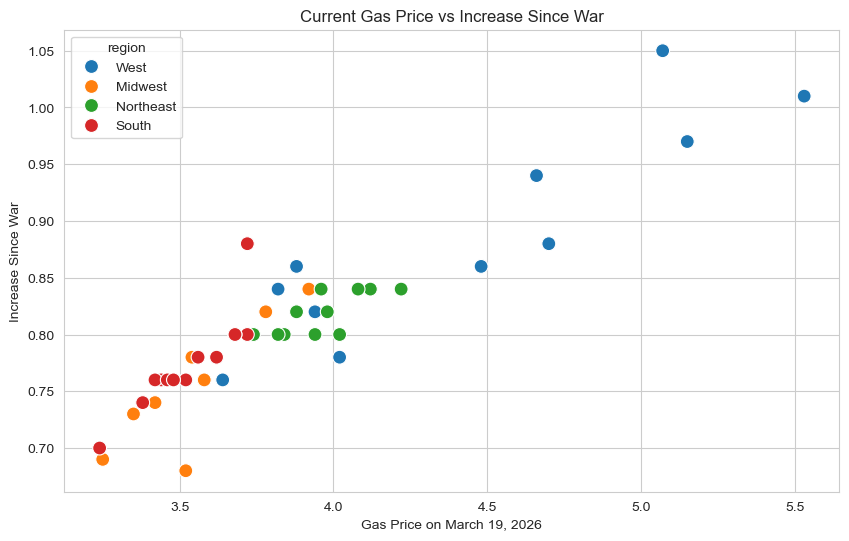

In [127]:
sns.scatterplot(data=df, x='gas_price_mar19_2026', y='price_increase_since_war', hue='region', s=100)
plt.title("Current Gas Price vs Increase Since War")
plt.xlabel("Gas Price on March 19, 2026")
plt.ylabel("Increase Since War")
plt.show()


# Box Plot: Gas Price Distribution by Region

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16512\3943501242.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='gas_price_mar19_2026',palette='Set2')


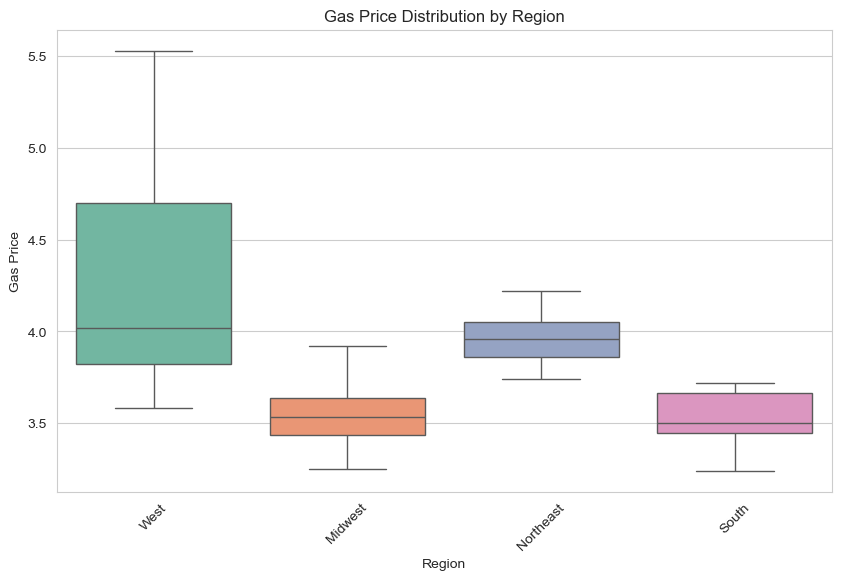

In [37]:
sns.boxplot(data=df, x='region', y='gas_price_mar19_2026',palette='Set2')
plt.title("Gas Price Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Gas Price")
plt.xticks(rotation=45)
plt.show()

# Key Insights

In [173]:
print("1. Gas prices increased in many states after the war-related market event.")
print("2. Some states experienced much sharper increases than others.")
print("3. Regional patterns suggest that certain regions had higher average gas prices.")
print("4. States above the national average indicate uneven fuel price burden.")
print("5. Geopolitical tension can strongly influence domestic fuel markets.")

1. Gas prices increased in many states after the war-related market event.
2. Some states experienced much sharper increases than others.
3. Regional patterns suggest that certain regions had higher average gas prices.
4. States above the national average indicate uneven fuel price burden.
5. Geopolitical tension can strongly influence domestic fuel markets.


# Conclusion:
### This project analyzed the impact of Iran war tensions on gas prices across U.S. states.
Using Python libraries like pandas, matplotlib, and seaborn, the dataset was cleaned,
analyzed, and visualized to understand price changes by state and region.
The study shows that geopolitical events can significantly affect fuel prices,
with varying impact across different states.